In [2]:
!pip3 install -r requirements.txt

In [3]:
from huggingface_hub import snapshot_download

In [4]:
dataset_path = snapshot_download(repo_id="biglab/webui-7k", repo_type="dataset")
dataset_path

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

'C:\\Users\\70133\\.cache\\huggingface\\hub\\datasets--biglab--webui-7k\\snapshots\\60f7b3c4b9409f75551664adc1564625dfc33c2e'

In [5]:
import enum
import os
import zipfile
import gzip
import json
from glob import glob
import re
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

In [6]:
# Create output dir
d1_path = os.path.join(dataset_path, "dataset1")
if not os.path.exists(d1_path):
    print("Empty dir, running mkdir...")
    os.mkdir(d1_path)

## Dataset decompression

This code will unpack files only for the first time

In [7]:
def unpack():
    # Merge 2 zip files
    files = glob(os.path.join(dataset_path, "*.zip*"))
    output = os.path.join(d1_path, "dataset.zip")
    if os.path.exists(output):
        return True # nothing to do
    
    os.system("cat " + ' '.join(sorted(files)) + " > " + output)

    d1_zip = os.path.realpath(output)
    if not zipfile.is_zipfile(d1_zip):
        print("WARNING : bad zip format")
        return False

    with zipfile.ZipFile(output, 'r') as z:
        z.extractall(d1_path)

    return True

In [8]:
unpack()

True

## Loading files

In [9]:
#r'C:\Users\70133\VS_Code_Projects\WebUI_Project\dataset'
files = os.path.join(d1_path, "train_split_web7k")
base_data_path = d1_path
print(files)
print("files number", len(os.listdir(files)))

C:\Users\70133\.cache\huggingface\hub\datasets--biglab--webui-7k\snapshots\60f7b3c4b9409f75551664adc1564625dfc33c2e\dataset1\train_split_web7k
files number 5420


In [10]:
# Load pages metadata

# TODO figure out a proper solution for storing metadata
meta_path = r"C:\Users\70133\VS_Code_Projects\jarvis-core"
# meta_path = "/home/flynn/src/jupyter"
# meta_path = "."

with open(os.path.join(meta_path, 'webui/metadata/screenclassification/class_map_enrico.json'), 'r') as f:
    labels = json.load(f)["idx2Label"].values()
#dtypes = {**{'page_id': object, 'file': object}, **dict([(x, np.float64) for x in labels])}
dtypes = {**{'page_id': np.int64, 'file': object}, **dict([(x, np.float64) for x in labels])}

df_c = pd.read_csv(os.path.join(meta_path, 'webui/metadata/screenclassification/silver_webui-multi_topic.csv'), sep=r'[,\\]', names=['page_id', 'file', *labels], dtype=dtypes, engine='python')

In [11]:
df_c.head(5)

,page_id,file,bare,calculator,camera,chat,editor,form,gallery,list,...,mediaplayer,menu,modal,news,other,profile,search,settings,terms,tutorial
0,1655879187811,default_1280-720-screenshot.webp,9.291674e-11,7.130765e-08,7.253227e-06,9.046539e-06,8.187051e-09,7.984676e-08,2.324591e-06,0.983791,...,9.630982e-06,5.211010e-05,1.108446e-03,1.410034e-02,1.907439e-04,2.310613e-08,4.906302e-05,4.191939e-05,6.378857e-04,7.004751e-08
1,1655879187811,default_1536-864-screenshot.webp,1.109577e-12,3.087419e-10,9.532457e-10,1.385165e-11,1.341835e-09,3.822118e-09,1.366081e-09,0.000013,...,6.291726e-08,8.763302e-11,1.148793e-04,3.088464e-07,9.998707e-01,1.503188e-10,1.038731e-09,1.253137e-10,5.714059e-08,9.233252e-07
2,1655879187811,iPad-Pro-screenshot.webp,4.476726e-10,2.628705e-07,4.739139e-05,8.027262e-07,1.768409e-09,3.327144e-06,2.086888e-06,0.946450,...,7.259951e-04,4.811632e-02,1.890350e-04,6.831510e-04,1.278714e-07,2.380704e-06,2.039391e-04,1.932175e-03,1.641989e-03,9.453231e-07
3,1655879187811,iPhone-13 Pro-screenshot.webp,1.740975e-11,2.117407e-08,2.220893e-10,6.500039e-13,3.749291e-13,8.293891e-10,1.001302e-10,0.000012,...,1.541007e-07,2.752847e-09,4.523345e-09,2.618951e-01,2.998420e-11,7.362105e-03,2.464764e-07,2.476263e-10,7.307301e-01,6.493919e-07
4,1655884447196,iPad-Pro-screenshot.webp,1.347118e-05,6.677556e-03,1.288787e-03,2.742077e-05,8.803538e-05,3.809738e-07,4.067358e-02,0.000673,...,1.043205e-06,1.424785e-03,7.473713e-06,2.308492e-01,6.170149e-07,1.024725e-01,6.051495e-01,2.472414e-05,9.113838e-05,8.508272e-03


In [12]:
# Take max of each screenshot and save it
df_c['label_max'] = df_c[labels].idxmax(axis=1)
df_c['certainty'] = df_c[labels].max(axis=1)

df_cf = (df_c.set_index(['page_id', 'file']).sort_index())      # index = (page_id, file)
assert df_cf.index.is_unique   

In [13]:
df_cf.head(5)

bare    calculator  \
page_id       file                                                           
1655879187811 default_1280-720-screenshot.webp  9.291674e-11  7.130765e-08   
              default_1536-864-screenshot.webp  1.109577e-12  3.087419e-10   
              iPad-Pro-screenshot.webp          4.476726e-10  2.628705e-07   
              iPhone-13 Pro-screenshot.webp     1.740975e-11  2.117407e-08   
1655884447196 iPad-Pro-screenshot.webp          1.347118e-05  6.677556e-03   

                                                      camera          chat  \
page_id       file                                                           
1655879187811 default_1280-720-screenshot.webp  7.253227e-06  9.046539e-06   
              default_1536-864-screenshot.webp  9.532457e-10  1.385165e-11   
              iPad-Pro-screenshot.webp          4.739139e-05  8.027262e-07   
              iPhone-13 Pro-screenshot.webp     2.220893e-10  6.500039e-13   
1655884447196 iPad-Pro-screenshot.webp          1.288787e-03  2.742077e-05   

                                                      editor          form  \
page_id       file                                                           
1655879187811 default_1280-720-screenshot.webp  8.187051e-09  7.984676e-08   
              default_1536-864-screenshot.webp  1.341835e-09  3.822118e-09   
              iPad-Pro-screenshot.webp          1.768409e-09  3.327144e-06   
              iPhone-13 Pro-screenshot.webp     3.749291e-13  8.293891e-10   
1655884447196 iPad-Pro-screenshot.webp          8.803538e-05  3.809738e-07   

                                                     gallery      list  \
page_id       file                                                       
1655879187811 default_1280-720-screenshot.webp  2.324591e-06  0.983791   
              default_1536-864-screenshot.webp  1.366081e-09  0.000013   
              iPad-Pro-screenshot.webp          2.086888e-06  0.946450   
              iPhone-13 Pro-screenshot.webp     1.001302e-10  0.000012   
1655884447196 iPad-Pro-screenshot.webp          4.067358e-02  0.000673   

                                                       login          maps  \
page_id       file                                                           
1655879187811 default_1280-720-screenshot.webp  4.828995e-08  6.712814e-12   
              default_1536-864-screenshot.webp  2.989208e-07  1.240250e-15   
              iPad-Pro-screenshot.webp          3.144533e-08  1.722613e-10   
              iPhone-13 Pro-screenshot.webp     1.002917e-11  3.034406e-12   
1655884447196 iPad-Pro-screenshot.webp          1.071961e-04  1.921105e-03   

                                                ...         modal  \
page_id       file                              ...                 
1655879187811 default_1280-720-screenshot.webp  ...  1.108446e-03   
              default_1536-864-screenshot.webp  ...  1.148793e-04   
              iPad-Pro-screenshot.webp          ...  1.890350e-04   
              iPhone-13 Pro-screenshot.webp     ...  4.523345e-09   
1655884447196 iPad-Pro-screenshot.webp          ...  7.473713e-06   

                                                        news         other  \
page_id       file                                                           
1655879187811 default_1280-720-screenshot.webp  1.410034e-02  1.907439e-04   
              default_1536-864-screenshot.webp  3.088464e-07  9.998707e-01   
              iPad-Pro-screenshot.webp          6.831510e-04  1.278714e-07   
              iPhone-13 Pro-screenshot.webp     2.618951e-01  2.998420e-11   
1655884447196 iPad-Pro-screenshot.webp          2.308492e-01  6.170149e-07   

                                                     profile        search  \
page_id       file                                                           
1655879187811 default_1280-720-screenshot.webp  2.310613e-08  4.906302e-05   
              default_1536-864-screenshot.webp  1.503188e-10  1.038731e-09   
      

In [14]:
df_cf["label_max"].value_counts()

label_max
tutorial       176323
news            82991
list            68810
gallery         64452
modal           56708
terms           55117
menu            44860
login           40232
profile         38755
mediaplayer     32966
bare            27064
other           14979
calculator      14120
search          13933
form            13678
settings        11339
camera           8813
editor           5108
chat             2117
maps             1966
Name: count, dtype: int64

## Dataset parsing

In [15]:
from page_loader import FileType, ft_is_gz, ft_is_json, ft_is_webp


In [16]:
from page_loader import Page, PageLoader


In [17]:
def label_certainty_thresh(c: np.float64) -> bool:      
    return c >= 0.6

In [18]:
def preview(img: Image.Image, width: int) -> Image.Image:
    return img.resize((width, int(img.height / img.width * width)))

1655891494288 1655891640247 1655891768961 1655892039279 1655892361993 
1655892622338 1655892912004 1655892957033 1655893400177 1655894038410 
1655894296122 1655894385457 1655894569252 1655894591547 1655894681459 
1655894826294 1655894855343 1655895071216 1655895108314 1655895221087 
1655895270374 1655895302939 1655895352316 1655895583558 1655895587739 


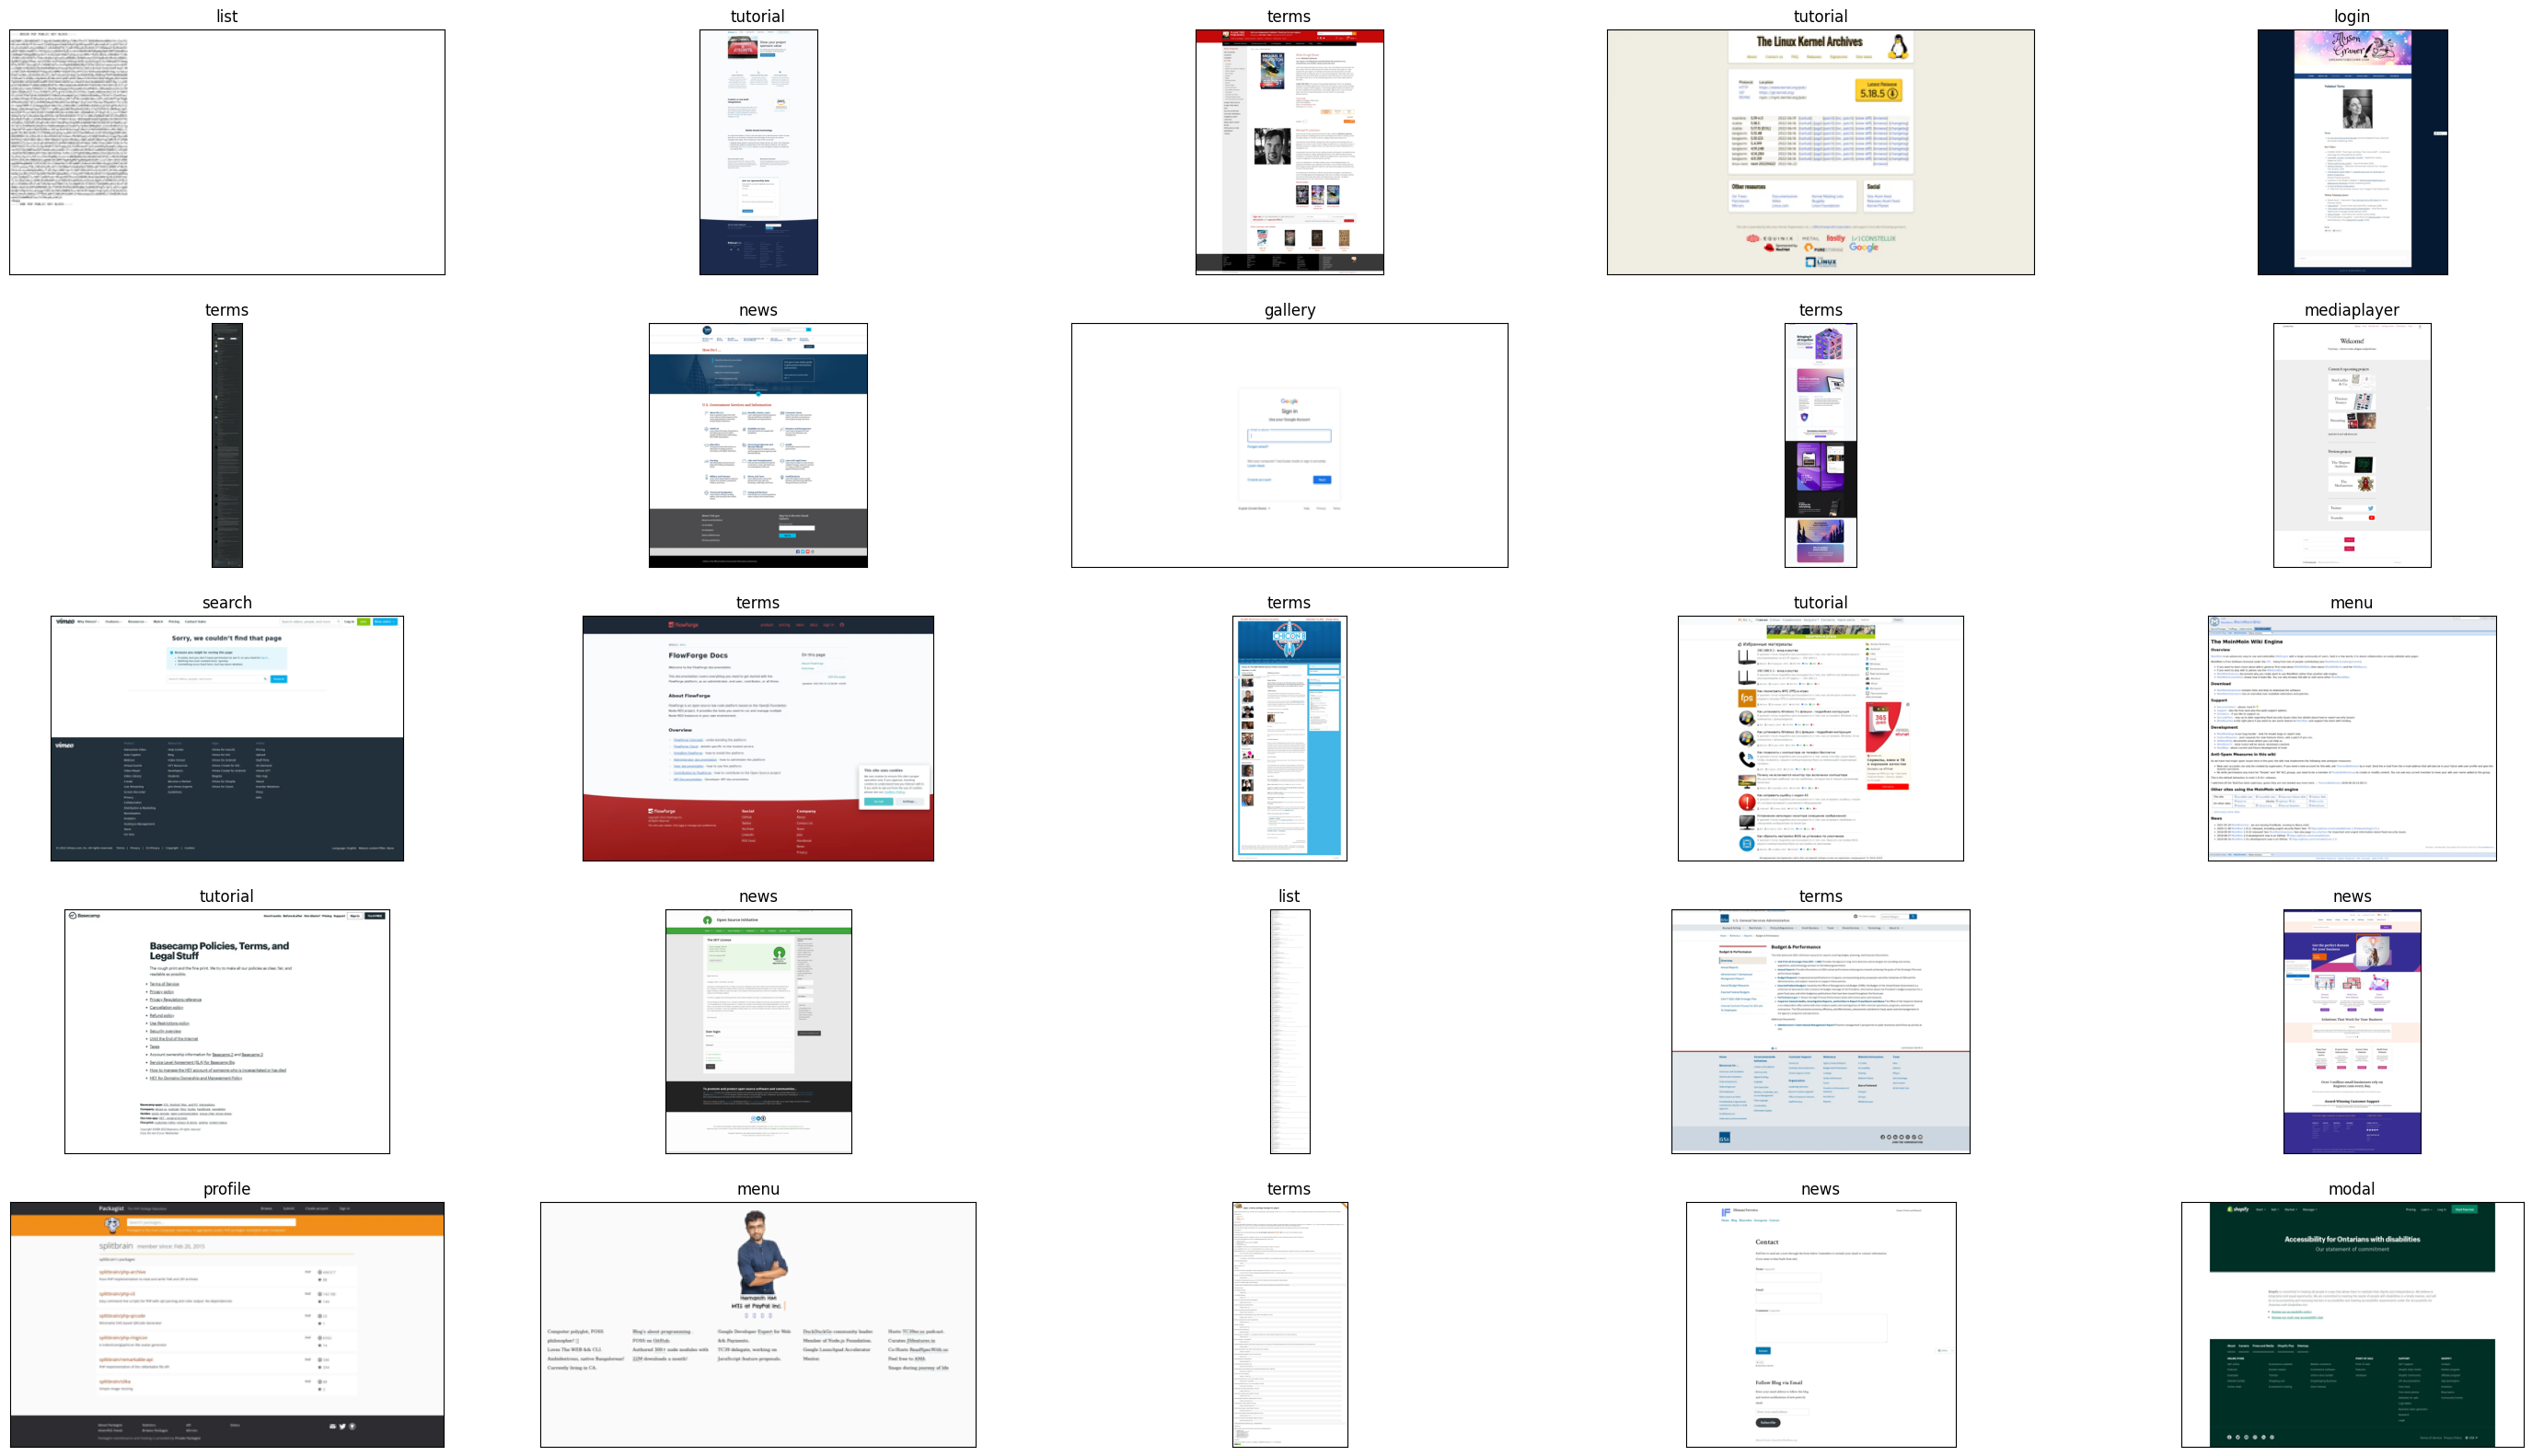

In [19]:
_ = plt.figure(figsize=(36, 20)) # 1920/1080 scaled to 360p
(nrows, ncols) = (5, 5) # Set the grid size
start = nrows*ncols # Start index
skip = 0

files_l = sorted(os.listdir(files))
# for index in range(0, nrows*ncols):
for index in range(0, nrows*ncols):
    while True: # Find matching
        fpath = files_l[index + start + skip]
        # Parse the page
        loader = PageLoader(os.path.join(files, fpath), debug=False, df_cf=df_cf)
        if not label_certainty_thresh(loader.certainty):
            skip += 1
            continue # Skip

        # Create a subplot and render an image
        ax = plt.subplot(nrows, ncols, index+1)
        _ = plt.title(loader.label)
        _, _ = plt.xticks([]), plt.yticks([]);
        image = loader.image()
        if image is not None:
            _ = plt.imshow(preview(image, 360))
            print(loader.page_id, end=' ')
            if index % ncols == 4:
                print('')
        else:
            skip += 1
            continue # Load the next sample
        # Else found
        break
_ = plt.show()

## Bounding Boxes

### Initialization

dict_keys(['default_1920-1080', 'default_1280-720', 'iPhone-13 Pro', 'default_1366-768', 'default_1536-864', 'iPad-Pro'])
screen_type: default_1920-1080 page_id: 1655890112189 label: menu


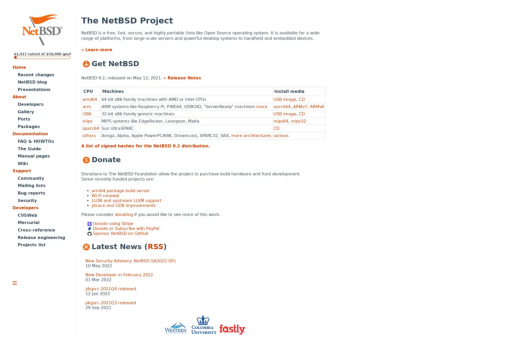

In [20]:
# Take 1655885631145 since it is in huggingface dataset
site_number = '1655890112189'  # 1655885744591      1655888953458       1655890112189
path = os.path.join(base_data_path, 'train_split_web7k', site_number) 
loader = PageLoader(path, debug=False, df_cf=df_cf)


# Show
print(loader.pages.keys())
print('screen_type:', loader.screen_type, 'page_id:', loader.page_id, 'label:', loader.label)
plt.imshow(loader.image())
plt.axis("off")
plt.show()

In [21]:
# AXTree
nodes = loader.best.files[FileType.AXTree]['nodes']
print(type(loader.best.files[FileType.AXTree]))
print(json.dumps(nodes, indent=2, ensure_ascii=False))

<class 'dict'>
[
  {
    "nodeId": "1",
    "ignored": false,
    "role": {
      "type": "internalRole",
      "value": "RootWebArea"
    },
    "name": {
      "type": "computedString",
      "value": "The NetBSD Project",
      "sources": [
        {
          "type": "relatedElement",
          "attribute": "aria-labelledby"
        },
        {
          "type": "attribute",
          "attribute": "aria-label"
        },
        {
          "type": "attribute",
          "attribute": "aria-label",
          "superseded": true
        },
        {
          "type": "relatedElement",
          "value": {
            "type": "computedString",
            "value": "The NetBSD Project"
          },
          "nativeSource": "title"
        },
        {
          "type": "attribute",
          "attribute": "title",
          "superseded": true
        }
      ]
    },
    "properties": [
      {
        "name": "focusable",
        "value": {
          "type": "booleanOrUndefined",
    

In [22]:
# BB
bb = loader.best.files.get(FileType.BB)

# turn bb keys to int
bb = { int(b_id): b for b_id, b in bb.items() }

print(type(bb))
for b_id, b in bb.items():
    print(b_id, b)

<class 'dict'>
3 {'x': 0, 'y': 0, 'width': 1920, 'height': 1080}
4 {'x': 316, 'y': 194.765625, 'width': 184, 'height': 33}
5 {'x': 276, 'y': 256.5, 'width': 950, 'height': 620.734375}
8 {'x': 349.5, 'y': 475.109375, 'width': 666, 'height': 28}
9 {'x': 0, 'y': 1042, 'width': 250, 'height': 38}
10 {'x': 276, 'y': 29.4375, 'width': 950, 'height': 1150.265625}
11 {'x': 276, 'y': 148.46875, 'width': 950, 'height': 20.796875}
12 {'x': 276, 'y': 193.265625, 'width': 950, 'height': 40}
13 {'x': 1015.5, 'y': 301.796875, 'width': 205, 'height': 33.3125}
14 {'x': 1015.5, 'y': 335.109375, 'width': 205, 'height': 28}
15 {'x': 953, 'y': 367.609375, 'width': 43, 'height': 19}
16 {'x': 1015.5, 'y': 363.109375, 'width': 205, 'height': 28}
17 {'x': 1161, 'y': 367.609375, 'width': 55, 'height': 19}
18 {'x': 276.5, 'y': 391.109375, 'width': 944, 'height': 28}
19 {'x': 1015.5, 'y': 391.109375, 'width': 205, 'height': 28}
20 {'x': 276.5, 'y': 419.109375, 'width': 944, 'height': 28}
21 {'x': 1015.5, 'y': 419

In [23]:
# map backendDOMNodeId -> AXTree node
backend_id_to_axnode = {
    node.get("backendDOMNodeId"): node
    for node in nodes
    if "backendDOMNodeId" in node
}

bb_info = {}
for b_id, b in bb.items():
    ax_node = backend_id_to_axnode.get(b_id)
    if not ax_node:
        continue

    bb_info[b_id] = {
        "name": ax_node.get("name", {}).get("value", ""),
        "name_t": ax_node.get("name", {}).get("type", ""),
        "role": ax_node.get("role", {}).get("value", ""),
        "role_t": ax_node.get("role", {}).get("type", ""),
        "ignored": ax_node.get("ignored", False),
        "box": b
    }

# print(type(backend_id_to_axnode), json.dumps(backend_id_to_axnode, indent=2, ensure_ascii=False))
print(type(bb_info),'\n', json.dumps(bb_info, indent=2, ensure_ascii=False))

<class 'dict'> 
 {
  "3": {
    "name": "The NetBSD Project",
    "name_t": "computedString",
    "role": "RootWebArea",
    "role_t": "internalRole",
    "ignored": false,
    "box": {
      "x": 0,
      "y": 0,
      "width": 1920,
      "height": 1080
    }
  },
  "4": {
    "name": "Get NetBSD",
    "name_t": "computedString",
    "role": "StaticText",
    "role_t": "internalRole",
    "ignored": false,
    "box": {
      "x": 316,
      "y": 194.765625,
      "width": 184,
      "height": 33
    }
  },
  "5": {
    "name": "",
    "name_t": "",
    "role": "none",
    "role_t": "role",
    "ignored": true,
    "box": {
      "x": 276,
      "y": 256.5,
      "width": 950,
      "height": 620.734375
    }
  },
  "8": {
    "name": "Amiga, Alpha, Apple PowerPC/68K, Dreamcast, SPARC32, VAX, more architectures",
    "name_t": "computedString",
    "role": "gridcell",
    "role_t": "role",
    "ignored": false,
    "box": {
      "x": 349.5,
      "y": 475.109375,
      "width": 666,


### Working with links

In [24]:
import importlib, axtree_html_mapper
importlib.reload(axtree_html_mapper)

from axtree_html_mapper import extract_all_anchors, map_axtree_links_to_html_hrefs, assert_mapping_quality

anchors = extract_all_anchors(loader.best.files[FileType.HTML])


mapping = map_axtree_links_to_html_hrefs(
    axtree=nodes,     # list или путь/объект (как у тебя)
    html=loader.best.files[FileType.HTML],          # <-- ВАЖНО: строка HTML
    base_url=loader.best.files[FileType.URL],
    resolve_urls=True
)
empty_cnt = sum(1 for v in mapping.values() if not v.get("href"))
print("HTML links count:", len(anchors), "AXTree links count: ", len(mapping), "Empty href count:", empty_cnt)

print(anchors[:5])
print(json.dumps(mapping, indent=2, ensure_ascii=False))


HTML links count: 68 AXTree links count:  66 Empty href count: 1
[{'i': 0, 'href': '#mainContent', 'text': 'Skip to main content.', 'aria_label': '', 'title': ''}, {'i': 1, 'href': './', 'text': '', 'aria_label': '', 'title': ''}, {'i': 2, 'href': '//www.NetBSD.org/donations/#how-to-donate', 'text': '', 'aria_label': '', 'title': ''}, {'i': 3, 'href': './', 'text': 'Home', 'aria_label': '', 'title': ''}, {'i': 4, 'href': './changes/', 'text': 'Recent changes', 'aria_label': '', 'title': ''}]
{
  "85": {
    "nodeId": "11",
    "href": "http://netbsd.org#mainContent",
    "ax_name": "Skip to main content.",
    "matched_html_name": "Skip to main content.",
    "score": "100"
  },
  "96": {
    "nodeId": "40",
    "href": "",
    "ax_name": "$2,417 raised of $50,000 goal",
    "matched_html_name": null,
    "score": "0"
  },
  "106": {
    "nodeId": "86",
    "href": "http://netbsd.org/donations/",
    "ax_name": "donating",
    "matched_html_name": "donating",
    "score": "100"
  },
  

In [25]:
from urllib.parse import urljoin

anchors = extract_all_anchors(loader.best.files[FileType.HTML])
nodes = loader.best.files[FileType.AXTree]['nodes']

base_url = loader.best.files[FileType.URL].strip()

def normalize_url(u: str) -> str:
    u = (u or "").strip()
    # Make "https://site#x" == "https://site/#x"
    if u.startswith("http") and "#" in u:
        before, frag = u.split("#", 1)
        if before.endswith("/") is False and "/" not in before.split("://", 1)[1]:
            # very conservative fix; easiest: always ensure slash before '#'
            pass
    # Simple, robust fix for your observed case:
    u = u.replace("https://libera.chat#", "https://libera.chat/#")
    return u

# 1) HTML anchors -> absolute hrefs
anchor_abs = []
for a in anchors:
    href_raw = a.get("href", "")
    if not href_raw:
        continue
    abs_u = urljoin(base_url, href_raw)
    anchor_abs.append(normalize_url(abs_u))

anchor_abs_set = set(anchor_abs)

# 2) mapping hrefs
mapping_hrefs = [
    normalize_url(v.get("href", ""))
    for v in mapping.values()
    if v.get("href", "")
]
mapping_set = set(mapping_hrefs)

print("HTML anchors (abs) unique:", len(anchor_abs_set))
print("Mapping hrefs unique:", len(mapping_set))

# 3) What HTML has but mapping doesn't
missing = sorted(anchor_abs_set - mapping_set)
print("Missing hrefs (in HTML but not in mapping):", len(missing))
for u in missing[:50]:
    print("MISSING:", u)

# 4) What mapping has but HTML doesn't (usually 0; useful sanity check)
extra = sorted(mapping_set - anchor_abs_set)
print("Extra hrefs (in mapping but not in HTML):", len(extra))
for u in extra[:50]:
    print("EXTRA:", u)

# 5) (optional) show the anchor rows for missing hrefs (first 20)
missing_set = set(missing)
print("\nExamples of missing anchors (original rows):")
shown = 0
for a in anchors:
    href_raw = a.get("href", "")
    if not href_raw:
        continue
    abs_u = normalize_url(urljoin(base_url, href_raw))
    if abs_u in missing_set:
        print(a)
        shown += 1
        if shown >= 20:
            break


HTML anchors (abs) unique: 63
Mapping hrefs unique: 60
Missing hrefs (in HTML but not in mapping): 3
MISSING: http://netbsd.org/about/disclaimer.html
MISSING: http://www.NetBSD.org/cgi-bin/feedback.cgi
MISSING: http://www.NetBSD.org/donations/#how-to-donate
Extra hrefs (in mapping but not in HTML): 0

Examples of missing anchors (original rows):
{'i': 2, 'href': '//www.NetBSD.org/donations/#how-to-donate', 'text': '', 'aria_label': '', 'title': ''}
{'i': 66, 'href': '//www.NetBSD.org/cgi-bin/feedback.cgi', 'text': 'Contact', 'aria_label': '', 'title': ''}
{'i': 67, 'href': 'about/disclaimer.html', 'text': 'Disclaimer', 'aria_label': '', 'title': ''}


In [26]:
from pathlib import Path

root = Path(r"C:\Users\70133\VS_Code_Projects\WebUI_Project\dataset\train_split_web7k")

# Names of all subfolders (only directories)
folder_names = [p.name for p in root.iterdir() if p.is_dir()]

# Sort as integers (your names look like timestamps)
folder_names.sort(key=lambda s: int(s))

In [27]:
import os
import re
from pathlib import Path
from collections import defaultdict
from html import unescape
from urllib.parse import urljoin
from tqdm.auto import tqdm


# assumes these exist in your notebook/project:
# PageLoader, FileType, extract_all_anchors

_WS_RE = re.compile(r"\s+")

def _unwrap_stringish(x):
    if x is None:
        return ""
    if isinstance(x, str):
        return x
    if isinstance(x, dict):
        if "value" in x:
            return _unwrap_stringish(x["value"])
        for k in ("name", "text", "label"):
            if k in x:
                return _unwrap_stringish(x[k])
        return ""
    if isinstance(x, list):
        for it in x:
            s = _unwrap_stringish(it)
            if s:
                return s
        return ""
    return str(x)

def normalize_text(x) -> str:
    s = _unwrap_stringish(x)
    s = unescape((s or "").strip())
    s = _WS_RE.sub(" ", s)
    return s

def normalize_url(u: str) -> str:
    u = (u or "").strip()
    # keep your known fix (extend as needed)
    u = u.replace("https://libera.chat#", "https://libera.chat/#")
    return u

def get_anchor_href(a: dict, base_url: str) -> str:
    href_raw = (a.get("href") or "").strip()
    if not href_raw:
        return ""
    return normalize_url(urljoin(base_url, href_raw))

def get_anchor_text(a: dict) -> str:
    direct_candidates = [
        a.get("text", ""),
        a.get("innerText", ""),
        a.get("textContent", ""),
        a.get("label", ""),
        a.get("aria_label", "") or a.get("aria-label", ""),
        a.get("title", ""),
    ]
    for c in direct_candidates:
        t = normalize_text(c)
        if t:
            return t

    child_keys = ("imgs", "images", "img", "children", "childNodes", "elements")
    for k in child_keys:
        v = a.get(k)
        if not v:
            continue
        if isinstance(v, dict):
            v = [v]
        if not isinstance(v, list):
            continue
        for el in v:
            if not isinstance(el, dict):
                continue
            for img_cand in (
                el.get("alt", ""),
                el.get("aria_label", "") or el.get("aria-label", ""),
                el.get("title", ""),
            ):
                t = normalize_text(img_cand)
                if t:
                    return t

    for k in ("img_alt", "image_alt", "alt"):
        t = normalize_text(a.get(k, ""))
        if t:
            return t
    for k in ("img_alts", "image_alts", "alts"):
        v = a.get(k)
        if isinstance(v, list):
            for it in v:
                t = normalize_text(it)
                if t:
                    return t

    return ""

def node_is_link(n: dict) -> bool:
    role = n.get("role")
    role_val = normalize_text(role.get("value")) if isinstance(role, dict) else normalize_text(role)
    if role_val.lower() == "link":
        return True

    props = n.get("properties")
    if isinstance(props, list):
        for p in props:
            if not isinstance(p, dict):
                continue
            if p.get("name") in ("role", "aria-role", "aria_role"):
                if normalize_text(p.get("value")).lower() == "link":
                    return True
    return False

def get_node_text(n: dict) -> str:
    candidates = [
        n.get("name"),
        n.get("accessibleName"),
        n.get("text"),
        n.get("value"),
    ]
    for c in candidates:
        t = normalize_text(c)
        if t:
            return t
    return ""

# -----------------------------------------------------------------------------
# LOOP OVER ALL SITE FOLDERS
# -----------------------------------------------------------------------------

base_data_path = r"C:\Users\70133\VS_Code_Projects\WebUI_Project\dataset"
root_dir = Path(base_data_path) / "train_split_web7k"

site_folders = [p for p in root_dir.iterdir() if p.is_dir() and p.name.isdigit()]
site_folders.sort(key=lambda p: int(p.name))

errors = []

# totals across all sites (NODE-BASED)
tot_nodes = 0

tot_only_nodes_nodes = 0           # nodes whose text not in anchors at all
tot_common_nodes = 0               # nodes whose text is present in anchors

tot_safe_1to1_nodes = 0            # nodes in "Safe matches"
tot_safe_multiple_nodes = 0        # nodes in "Safe multiple"
tot_indistinguishable_nodes = 0    # nodes in "indistinguishable"
tot_all_other_nodes = 0            # nodes in "all other"

# Only-in-anchors can't be node-based; keep for reference
tot_only_anchors_texts = 0
tot_only_anchors_anchor_elems = 0

pbar = tqdm(site_folders, total=len(site_folders), desc="Sites", unit="site")

for idx, site_path in enumerate(pbar, start=1):
    try:
        loader = PageLoader(str(site_path), debug=False, df_cf=df_cf)

        anchors = extract_all_anchors(loader.best.files[FileType.HTML])
        nodes = loader.best.files[FileType.AXTree]["nodes"]
        base_url = loader.best.files[FileType.URL].strip()

        # ---------------------------
        # Collect anchor items
        # ---------------------------
        anchor_items = []
        for i, a in enumerate(anchors):
            t = get_anchor_text(a)
            if not t:
                continue
            href = get_anchor_href(a, base_url)
            if not href:
                continue
            anchor_items.append({"i": i, "text": t, "href": href, "raw": a})

        # ---------------------------
        # Collect node (link) items
        # ---------------------------
        node_items = []
        for j, n in enumerate(nodes):
            if not node_is_link(n):
                continue
            t = get_node_text(n)
            if not t:
                continue
            node_items.append({"j": j, "text": t, "raw": n})

        tot_nodes += len(node_items)

        # ---------------------------
        # Build indices
        # ---------------------------
        anchors_by_text_href = defaultdict(lambda: defaultdict(list))
        for it in anchor_items:
            anchors_by_text_href[it["text"]][it["href"]].append(it)

        nodes_by_text = defaultdict(list)
        for it in node_items:
            nodes_by_text[it["text"]].append(it)

        anchor_text_set = set(anchors_by_text_href.keys())
        node_text_set = set(nodes_by_text.keys())

        only_nodes_texts = node_text_set - anchor_text_set
        only_anchors_texts = anchor_text_set - node_text_set
        common_texts = node_text_set & anchor_text_set

        # only in nodes (COUNT BY NODES)
        for t in only_nodes_texts:
            tot_only_nodes_nodes += len(nodes_by_text[t])

        # only in anchors (NOT node-based, keep for reference)
        tot_only_anchors_texts += len(only_anchors_texts)
        for t in only_anchors_texts:
            href_map = anchors_by_text_href[t]
            anchors_count = sum(len(lst) for lst in href_map.values())
            tot_only_anchors_anchor_elems += anchors_count

        # common (COUNT BY NODES)
        for t in common_texts:
            n_list = nodes_by_text[t]
            href_map = anchors_by_text_href[t]

            nodes_count = len(n_list)
            unique_hrefs_count = len(href_map)  # href keys
            anchors_count = sum(len(lst) for lst in href_map.values())

            tot_common_nodes += nodes_count

            # Safe 1-to-1
            if nodes_count == 1 and unique_hrefs_count == 1:
                tot_safe_1to1_nodes += nodes_count
                continue

            # Safe multiple
            if nodes_count > 1 and unique_hrefs_count == 1 and anchors_count >= nodes_count:
                tot_safe_multiple_nodes += nodes_count
                continue

            # indistinguishable (anchors_count == nodes_count, href not all same)
            if nodes_count > 1 and anchors_count == nodes_count and unique_hrefs_count > 1:
                tot_indistinguishable_nodes += nodes_count
                continue

            # all other
            tot_all_other_nodes += nodes_count

    except Exception as e:
        errors.append((site_path.name, repr(e)))

    # Обновляем прогресс-бар (каждую итерацию — нормально)
    safe_nodes = tot_safe_1to1_nodes + tot_safe_multiple_nodes
    pbar.set_postfix({
        "errs": len(errors),
        "safe": f"{safe_nodes}/{tot_nodes}" if tot_nodes else "0/0",
        "common": tot_common_nodes,
        "onlyN": tot_only_nodes_nodes,
        "indist": tot_indistinguishable_nodes,
        "other": tot_all_other_nodes,
    })


# -----------------------------------------------------------------------------
# FINAL OUTPUT (across ALL sites)
# -----------------------------------------------------------------------------

print("\nProcessed sites:", len(site_folders) - len(errors), "/", len(site_folders))
print("Errors:", len(errors))
if errors:
    print("First 10 errors:")
    for site, err in errors[:10]:
        print("-", site, err)

print("\nTotal nodes:", tot_nodes)

print("\nOnly in nodes (nodes):", tot_only_nodes_nodes)
print("Only in anchors (texts):", tot_only_anchors_texts)
print("Only in anchors (anchor elems):", tot_only_anchors_anchor_elems)

print("\nCommon (nodes):", tot_common_nodes)
print("Safe matches (nodes=1, anchors unique href=1) [nodes]:", tot_safe_1to1_nodes)
print("Safe multiple (nodes=K, 1 href, anchors>=nodes) [nodes]:", tot_safe_multiple_nodes)
print("indistinguishable (nodes=K, anchors=K, href not all same) [nodes]:", tot_indistinguishable_nodes)
print("all other (same text -> multiple hrefs) [nodes]:", tot_all_other_nodes)

safe_nodes = tot_safe_1to1_nodes + tot_safe_multiple_nodes
print("\nNode coverage (safe):", safe_nodes, "/", tot_nodes)

# sanity check for node accounting (optional)
# print("SANITY:",
#       tot_only_nodes_nodes + tot_common_nodes, "==", tot_nodes,
#       "| common split:",
#       tot_safe_1to1_nodes + tot_safe_multiple_nodes + tot_indistinguishable_nodes + tot_all_other_nodes, "==", tot_common_nodes)


Sites:   0%|          | 0/5420 [00:00<?, ?site/s]


Processed sites: 5379 / 5420
Errors: 41
First 10 errors:
- 1655952234938 AttributeError("'NoneType' object has no attribute 'files'")
- 1655970089332 AttributeError("'NoneType' object has no attribute 'files'")
- 1655971151261 OSError(22, 'Invalid argument')
- 1655983916641 AttributeError("'NoneType' object has no attribute 'files'")
- 1655984806105 AttributeError("'NoneType' object has no attribute 'files'")
- 1655987792429 AttributeError("'NoneType' object has no attribute 'files'")
- 1655987940330 AttributeError("'NoneType' object has no attribute 'files'")
- 1655998158694 OSError(22, 'Invalid argument')
- 1656006596157 AttributeError("'NoneType' object has no attribute 'files'")
- 1656007194101 OSError(22, 'Invalid argument')

Total nodes: 230814

Only in nodes (nodes): 42398
Only in anchors (texts): 64351
Only in anchors (anchor elems): 92861

Common (nodes): 188416
Safe matches (nodes=1, anchors unique href=1) [nodes]: 115444
Safe multiple (nodes=K, 1 href, anchors>=nodes) [node

In [30]:
# Update bb_info names with hrefs from mapping
for b_id in bb_info.keys():
    m = mapping.get(b_id)

    # handle str/int key mismatch
    if m is None:
        if isinstance(b_id, str):
            try:
                m = mapping.get(int(b_id))
            except ValueError:
                m = None
        else:
            m = mapping.get(str(b_id))

    if not m:
        continue

    # overwrite name with href (even if empty, keep as empty string)
    bb_info[b_id]["name"] = m.get("href", "")


### Filtering 

In [31]:
ignored_ids = [] 
for x_id, x in bb_info.items():
    if x["ignored"] == True:
        print(x_id, x['ignored'], x['role_t'], x['role'], '"', x['name'], '"', x['box'])
        ignored_ids.append(x_id)

print(set(ignored_ids))

5 True role none "  " {'x': 276, 'y': 256.5, 'width': 950, 'height': 620.734375}
37 True role none "  " {'x': 46.5625, 'y': 4.796875, 'width': 156.859375, 'height': 152}
41 True role none "  " {'x': 276, 'y': 301.296875, 'width': 950, 'height': 202.3125}
44 True role none "  " {'x': 276.5, 'y': 335.109375, 'width': 944, 'height': 168}
60 True role none "  " {'x': 0, 'y': 0, 'width': 1920, 'height': 8}
61 True role none "  " {'x': 360, 'y': 8, 'width': 1200, 'height': 0}
62 True role none "  " {'x': 360, 'y': 8, 'width': 1200, 'height': 0}
64 True role none "  " None
66 True role none "  " None
67 True role none "  " None
68 True role none "  " None
69 True role none "  " None
70 True role none "  " None
71 True role none "  " None
72 True role none "  " None
73 True role none "  " None
74 True role none "  " None
75 True role none "  " None
76 True role none "  " None
77 True role none "  " None
78 True role none "  " None
79 True role none "  " None
80 True role none "  " None
81 True

In [32]:
unic = {info["name_t"] for info in bb_info.values()}
print(unic)

{'', 'computedString'}


In [33]:
# roles filter
allowed_roles = {info["role"] for info in bb_info.values()}
print(allowed_roles)
# allowed_roles.discard('StaticText')
# allowed_roles.discard('heading')
# allowed_roles.discard('paragraph')
# allowed_roles.discard('RootWebArea')
# allowed_roles.discard('navigation')

{'table', 'none', 'StaticText', 'navigation', 'generic', 'row', 'heading', 'list', 'LineBreak', 'RootWebArea', 'img', 'ListMarker', 'columnheader', 'LabelText', 'link', 'paragraph', 'gridcell', 'listitem'}


In [48]:
def rectangle_intersaction_area_pr(p, c):
    if(p["width"] == 0 or p["height"] == 0):
        return 0
    # Координаты пересечения
    x_left   = max(p["x"], c["x"])
    y_bottom = max(p["y"], c["y"])
    x_right  = min(p["x"] + p["width"], c["x"] + c["width"])
    y_top    = min(p["y"] + p["height"], c["y"] + c["height"])
    
    # Проверка: есть ли вообще пересечение
    if x_right > x_left and y_top > y_bottom:
        parent_area = p["width"] * p["height"]
        return (x_right - x_left) * (y_top - y_bottom) / parent_area
    else:
        return 0  # Нет пересечения

In [35]:
nodes_by_id = {node["nodeId"]: node for node in nodes}


statictext_child_counts = []

for node_id, node in nodes_by_id.items():
    role_info = node.get("role")
    if role_info and role_info.get("value") == "StaticText":
        child_ids = node.get("childIds", [])
        count = len(child_ids)
        statictext_child_counts.append((node_id, count))

# Вывод
print("Узлы с role_value = 'StaticText' и количеством дочерних элементов:")
for node_id, count in statictext_child_counts:
    print(f"Node {node_id}: {count} child(ren)")


Узлы с role_value = 'StaticText' и количеством дочерних элементов:
Node 39: 0 child(ren)
Node 46: 0 child(ren)
Node 54: 0 child(ren)
Node 56: 0 child(ren)
Node 58: 0 child(ren)
Node 60: 0 child(ren)
Node 62: 0 child(ren)
Node 66: 0 child(ren)
Node 68: 0 child(ren)
Node 31: 0 child(ren)
Node 43: 0 child(ren)
Node 200: 0 child(ren)
Node 201: 0 child(ren)
Node 94: 0 child(ren)
Node 79: 0 child(ren)
Node 331: 0 child(ren)
Node 213: 0 child(ren)
Node 254: 0 child(ren)
Node 257: 0 child(ren)
Node 260: 0 child(ren)
Node 263: 0 child(ren)
Node 270: 0 child(ren)
Node 271: 0 child(ren)
Node 273: 0 child(ren)
Node 277: 0 child(ren)
Node 281: 0 child(ren)
Node 282: 0 child(ren)
Node 284: 0 child(ren)
Node 289: 0 child(ren)
Node 293: 0 child(ren)
Node 297: 0 child(ren)
Node 302: 0 child(ren)
Node 305: 0 child(ren)
Node 308: 0 child(ren)
Node 311: 0 child(ren)
Node 318: 0 child(ren)
Node 322: 0 child(ren)
Node 323: 0 child(ren)
Node 325: 0 child(ren)
Node 329: 0 child(ren)
Node 330: 0 child(ren)
Nod

In [36]:
nodes_by_id = {node["nodeId"]: node for node in nodes}
print(type(nodes_by_id), json.dumps(nodes_by_id, indent=2, ensure_ascii=False))

<class 'dict'> {
  "1": {
    "nodeId": "1",
    "ignored": false,
    "role": {
      "type": "internalRole",
      "value": "RootWebArea"
    },
    "name": {
      "type": "computedString",
      "value": "Only Soccer Games",
      "sources": [
        {
          "type": "relatedElement",
          "attribute": "aria-labelledby"
        },
        {
          "type": "attribute",
          "attribute": "aria-label"
        },
        {
          "type": "attribute",
          "attribute": "aria-label",
          "superseded": true
        },
        {
          "type": "relatedElement",
          "value": {
            "type": "computedString",
            "value": "Only Soccer Games"
          },
          "nativeSource": "title"
        },
        {
          "type": "attribute",
          "attribute": "title",
          "superseded": true
        }
      ]
    },
    "properties": [
      {
        "name": "focusable",
        "value": {
          "type": "booleanOrUndefined",
 

In [37]:
nodes_by_id = {node["nodeId"]: node for node in nodes}
# print(type(nodes_by_id), json.dumps(nodes_by_id, indent=2, ensure_ascii=False))

root_node = next(
    node for node in nodes
    if "parentId" not in node or node["parentId"] is None
)
# print(root_node.get("childIds", []))

# def build_tree(node):
#     children = []
#     for child_id in node.get("childIds", []):
#         child_node = nodes_by_id.get(child_id)
#         if child_node:
#             children.append(build_tree(child_node))
#     return {
#         "id": node["nodeId"],
#         "back_id": node.get("backendDOMNodeId"),
#         "ignored": node.get("ignored"),
#         "name": node.get("name", {}).get("value", ""),
#         "role": node.get("role", {}).get("value", ""),
#         "children": children
#     }

def build_tree(node):
    children = []
    for child_id in node.get("childIds", []):
        child_node = nodes_by_id.get(child_id)
        if child_node:
            child_back_id = child_node.get("backendDOMNodeId")
            child_box = bb.get(child_back_id) if child_back_id is not None else None
            parent_back_id = node.get("backendDOMNodeId")
            parent_box = bb.get(parent_back_id) if parent_back_id is not None else None

            # По умолчанию площадь пересечения — 0
            intersection_area = 0
            if parent_box and child_box:
                intersection_area = rectangle_intersaction_area_pr(parent_box, child_box)

            child_tree = build_tree(child_node)
            child_tree["intersection_area"] = intersection_area
            children.append(child_tree)

    return {
        "id": node["nodeId"],
        "back_id": node.get("backendDOMNodeId"),
        "ignored": node.get("ignored"),
        "name": node.get("name", {}).get("value", ""),
        "role": node.get("role", {}).get("value", ""),
        "children": children
    }

# вызов
tree = build_tree(root_node)
tree["intersection_area"] = 0


def print_tree(node, indent=0):
    if not isinstance(node, dict):
        print("Unexpected node:", node)
        return

    prefix = " " * (indent * 2)
    role = node.get("role", "")
    name = node.get("name", "")
    n_id = node.get("id", "")
    b_id = node.get("back_id", "")
    ignored = node.get("ignored", "")
    in_area = node.get("intersection_area", "")
    if float(in_area) > 0.5:
        print(f"{prefix}- {b_id} ({in_area}) ({indent}) ({role}) ({ignored}) ")

    for child in node.get("children", []):
        print_tree(child, indent + 1)

print_tree(tree)

In [38]:
def build_tree(node):
    children = []
    for child_id in node.get("childIds", []):
        child_node = nodes_by_id.get(child_id)
        if child_node:
            children.append(build_tree(child_node))

    return {
        "id": node["nodeId"],
        "back_id": node.get("backendDOMNodeId"),
        "ignored": node.get("ignored"),
        "name": node.get("name", {}).get("value", ""),
        "role": node.get("role", {}).get("value", ""),
        "modified": False,
        "children": children
    }


def print_tree(node, indent=0):
    if not isinstance(node, dict):
        print("Unexpected node:", node)
        return

    prefix = " " * (indent * 2)
    role = node.get("role", "")
    name = node.get("name", "")
    n_id = node.get("id", "")
    b_id = node.get("back_id", "")
    ignored = node.get("ignored", "")
    modified = node.get("modified", "")
    print(f"{prefix}- {b_id} ({ignored}) ({indent}) ({role})")

    for child in node.get("children", []):
        print_tree(child, indent + 1)

def is_useless_branch(node):
    """Возвращает True, если это ветка из ignored-узлов с role=none"""
    if not node.get("ignored", False):
        return False
    if node.get("role") != "none":
        return False
    if not node.get("children"):
        return True
    return all(is_useless_branch(child) for child in node["children"])

In [39]:
nodes_by_id = {node["nodeId"]: node for node in nodes}
# print(type(nodes_by_id), json.dumps(nodes_by_id, indent=2, ensure_ascii=False))
root_node = next(
    node for node in nodes
    if "parentId" not in node or node["parentId"] is None
)
# print(root_node.get("childIds", []))

def transform_tree(node):
    global mod_count, mod_name_count 
    global valid_b_ids
    # if node["ignored"] == False:
    valid_b_ids.append(node["back_id"])

    cleaned_children = []
    for child in node.get("children", []):
        if not is_useless_branch(child):
            cleaned_children.append(child)

    node["children"] = cleaned_children
    
    new_children = []
    skip = False

    # If only one child
    if len(node["children"]) == 1:
        child = node["children"][0]
        if (child["role"] in ["StaticText", "link", "heading", "paragraph", "gridcell"] and child["name"]):
           # or (child["ignored"] == True and len(child["children"]) == 0):
            print(f"before role: {node['role']}\tafter role: {child['role']}\t before name: {node['name']} after name: {child['name']}")
            if node["name"]:
                mod_name_count += 1
            node["name"] = child["name"]
            node["modified"] = True
            mod_count += 1
            skip = True  # skip child

    # Traverse the other children
    if not skip:
        for child in node["children"]:
            if is_useless_branch(child):
                continue
            transformed_child = transform_tree(child)
            new_children.append(transformed_child)

    node["children"] = new_children
    return node


valid_b_ids = []
mod_count = 0
mod_name_count = 0

tree = build_tree(root_node)
tree = transform_tree(tree)

print(f"\nModified nodes: {mod_count} \t chaged names: {mod_name_count}")
print(len(valid_b_ids), 'vs' , len(nodes_by_id), '\n', valid_b_ids, '\n')
print_tree(tree)

before role: LayoutTableCell	after role: StaticText	 before name:   after name:  
before role: paragraph	after role: StaticText	 before name:  after name: Welcome to Only Soccer Games.  This site is devoted exclusively to free online flash soccer games.  Enjoy!
before role: LayoutTableCell	after role: StaticText	 before name:   after name:  
before role: link	after role: StaticText	 before name: Carling Shootout after name: Carling Shootout
before role: link	after role: StaticText	 before name: The Champions 07 after name: The Champions 07
before role: link	after role: StaticText	 before name: The Champions 2 after name: The Champions 2
before role: LayoutTableCell	after role: StaticText	 before name:   after name:  
before role: LayoutTableCell	after role: StaticText	 before name:   after name:  
before role: LayoutTableCell	after role: StaticText	 before name:   after name:  
before role: link	after role: StaticText	 before name: Elastic Soccer after name: Elastic Soccer
before role:

### Print

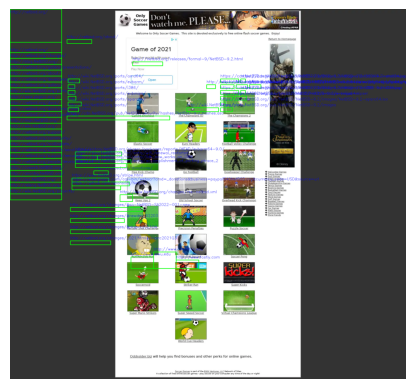

Image saved in: C:\Users\70133\VS_Code_Projects\WebUI_Project\dataset\bb\boxed.png


In [40]:
pil_img = loader.image()                                    # WebPImageFile
img_rgb = np.array(pil_img)                                 # RGB
img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)          # BGR for OpenCV

# Draw boxes
for b_id, b in bb.items():
    if b is None or b["width"] == 0 or b["height"] == 0:
        continue
    if not bb_info[b_id]["role"] == 'link': continue # filter by role

    if b_id in ignored_ids: continue # filter ignored nodes
    # if not b_id in valid_b_ids: # remove addintional nodes
    #     continue
    color_b = (0, 255, 0)
    color_t = (255, 0, 0)
    # if b_id in {3, 117, 119, 38, 39, 51, 118, 40, 128, 129}: 
    #     color_b = (0, 0, 255)
    #     color_t = (0, 0, 0)

    
    x1, y1 = int(b["x"]), int(b["y"])
    x2 = int(b["x"] + b["width"])
    y2 = int(b["y"] + b["height"])
    
    name = bb_info[b_id]["name"]
    role = bb_info[b_id]["role"]
    text_coordinates = (x1, max(y1 - 8, 0))
    if y1 < 20:
        text_coordinates = (x1, max(y1 + 20, 0))
    
    cv2.rectangle(img_bgr, (x1, y1), (x2, y2), color_b, 2) # Green, width = 2px
    cv2.putText(img_bgr, str(name), text_coordinates, cv2.FONT_HERSHEY_SIMPLEX, 0.6, color_t, 1) # Text

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) # Back to RGB

# Show
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

# Save
out_dir = os.path.join(base_data_path, 'bb')
os.makedirs(out_dir, exist_ok=True)
#out_dir.mkdir(parents=True, exist_ok=True)
out_path = os.path.join(out_dir, "boxed.png")

if not cv2.imwrite(str(out_path), img_bgr):
    raise RuntimeError("error")
print("Image saved in:", out_path)

## Other Bounding Boxes

In [41]:
def get_bb_and_info(filename):
    path = os.path.join(base_data_path, 'train_split_web7k', filename)
    loader = PageLoader(path, debug=False, df_cf=df_cf)
    
    # AXTree
    nodes = loader.best.files[FileType.AXTree]['nodes']
    
    # BB
    bb = loader.best.files.get(FileType.BB)
    bb = { int(b_id): b for b_id, b in bb.items() } # turn bb keys to int
    
    # map backendDOMNodeId -> AXTree node
    backend_id_to_axnode = {
        node.get("backendDOMNodeId"): node
        for node in nodes
        if "backendDOMNodeId" in node
    }
    
    bb_info = {}
    for b_id, b in bb.items():
        ax_node = backend_id_to_axnode.get(b_id)
        if not ax_node:
            continue
    
        bb_info[b_id] = {
            "name": ax_node.get("name", {}).get("value", ""),
            # "name_t": ax_node.get("name", {}).get("type", ""),
            "role": ax_node.get("role", {}).get("value", ""),
            # "role_t": ax_node.get("role", {}).get("type", ""),
            "ignored": ax_node.get("ignored", False),
            # "box": b
        }

    # Show
    print(loader.pages.keys())
    print('screen_type:', loader.screen_type, 'page_id:', loader.page_id, 'label:', loader.label)
    plt.imshow(loader.image())
    plt.axis("off")
    plt.show()
    # print(type(loader.best.files[FileType.AXTree]))
    # print(json.dumps(nodes, indent=2, ensure_ascii=False))
    # print(type(bb))
    # for b_id, b in bb.items():
    #     print(b_id, b)
    # print(type(backend_id_to_axnode), json.dumps(backend_id_to_axnode, indent=2, ensure_ascii=False))
    # print(type(bb_info),'\n', json.dumps(bb_info, indent=2, ensure_ascii=False))

    return bb, bb_info, loader.image()

In [42]:
def boxed_image(pil_img, bb, bb_info, out_dir, p_name = ''):
    img_rgb = np.array(pil_img)                                 # RGB
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)          # BGR for OpenCV
    
    # Draw boxes
    for b_id, b in bb.items():
        if b is None or b["width"] == 0 or b["height"] == 0:
            continue
            
        color_b = (0, 255, 0)
        color_t = (255, 0, 0)
        
        x1, y1 = int(b["x"]), int(b["y"])
        x2 = int(b["x"] + b["width"])
        y2 = int(b["y"] + b["height"])
        
        name = bb_info[b_id]["name"]
        role = bb_info[b_id]["role"]
        
        text_coordinates = (x1, max(y1 - 8, 0))
        if y1 < 20:
            text_coordinates = (x1, max(y1 + 20, 0))
            
        if str(role) == p_name:
            cv2.rectangle(img_bgr, (x1, y1), (x2, y2), color_b, 2) # Green, width = 2px
            cv2.putText(img_bgr, str(b_id), text_coordinates, cv2.FONT_HERSHEY_SIMPLEX, 0.6, color_t, 1) # Text
    
    cv2.putText(img_bgr, p_name, (10, 150), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2) # Text

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) # Back to RGB
    
    # Show
    # plt.imshow(img_rgb)
    # plt.axis("off")
    # plt.show()

    # Save
    os.makedirs(out_dir, exist_ok=True)
    # out_dir.mkdir(parents=True, exist_ok=True)
    out_path = os.path.join(out_dir, f"boxed_{p_name}.png")
    
    if not cv2.imwrite(str(out_path), img_bgr):
        raise RuntimeError("error")
    print(f"Role:{p_name}. Image saved in:", out_path)

In [43]:
# sites_to_go = {'1655885631145', '1655888953458', '1655890112189'}

# for site in sites_to_go:
#     bb1, bb_info1, img = get_bb_and_info(site)
    
#     allowed_roles1 = {info["role"] for info in bb_info1.values()}
#     print(allowed_roles1)
    
#     out_dir1 = os.path.join(base_data_path, 'bb', site)
    
#     for role in allowed_roles1:
#         boxed_image(img, bb1, bb_info1, out_dir1, role)

In [44]:
roles_unic = {'complementary', 'figure', 'button', 'tab', 'none', 'LayoutTableCell', 'tablist', 'article', 'IframePresentational',
              'Legend', 'navigation', 'gridcell', 'Section', 'spinbutton', 'DisclosureTriangle', 'img', 'DescriptionList', 'searchbox',
              'RootWebArea', 'group', 'Figcaption', 'row', 'Iframe', 'combobox', 'Pre', 'heading', 'menubar', 'DescriptionListDetail', 'menu',
              'separator', 'region', 'LineBreak', 'HeaderAsNonLandmark', 'columnheader', 'emphasis', 'listbox', 'rowheader', 'form', 'option',
              'textbox', 'link', 'LabelText', 'MenuListPopup', 'contentinfo', 'alertdialog', 'FooterAsNonLandmark', 'dialog', 'paragraph',
              'status', 'ListMarker', 'main', 'switch', 'Video', 'Abbr', 'tabpanel', 'grid', 'time', 'table', 'StaticText', 'listitem',
              'DescriptionListTerm', 'insertion', 'PluginObject', 'checkbox', 'menuitem', 'superscript', 'generic', 'banner', 'list',
              'LayoutTableRow', 'strong', 'LayoutTable', 'search', 'blockquote', 'Details'}
print(sorted(roles_unic))

['Abbr', 'DescriptionList', 'DescriptionListDetail', 'DescriptionListTerm', 'Details', 'DisclosureTriangle', 'Figcaption', 'FooterAsNonLandmark', 'HeaderAsNonLandmark', 'Iframe', 'IframePresentational', 'LabelText', 'LayoutTable', 'LayoutTableCell', 'LayoutTableRow', 'Legend', 'LineBreak', 'ListMarker', 'MenuListPopup', 'PluginObject', 'Pre', 'RootWebArea', 'Section', 'StaticText', 'Video', 'alertdialog', 'article', 'banner', 'blockquote', 'button', 'checkbox', 'columnheader', 'combobox', 'complementary', 'contentinfo', 'dialog', 'emphasis', 'figure', 'form', 'generic', 'grid', 'gridcell', 'group', 'heading', 'img', 'insertion', 'link', 'list', 'listbox', 'listitem', 'main', 'menu', 'menubar', 'menuitem', 'navigation', 'none', 'option', 'paragraph', 'region', 'row', 'rowheader', 'search', 'searchbox', 'separator', 'spinbutton', 'status', 'strong', 'superscript', 'switch', 'tab', 'table', 'tablist', 'tabpanel', 'textbox', 'time']


## Image viewer

In [45]:
bb_path = os.path.join("output", "bb")

In [46]:
pages = os.listdir(bb_path)
pages

['1655885631145',
 '1655888953458',
 '1655890112189',
 'boxed.png',
 'boxed_full.png',
 'boxed_half.png',
 'boxed_links.png',
 'boxed_links1.png',
 'boxed_links2.png',
 'boxed_links3.png',
 'boxed_min.png',
 'default_1280-720-axtree.json',
 'default_1920-1080-axtree.json']

In [47]:
# cur_page = 0
# fpath = os.path.join(bb_path, pages[cur_page])
# print(os.listdir(fpath))

# for fname in os.listdir(fpath):
#     print(fname)
#     #with open(os.path.join(fpath, fname), 'rb') as f:
#     img = Image.open(os.path.join(fpath, fname))
#     _ = plt.imshow(img)
#     _ = plt.axis("off")
#     plt.show()